=== Sales Data ===
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None

===

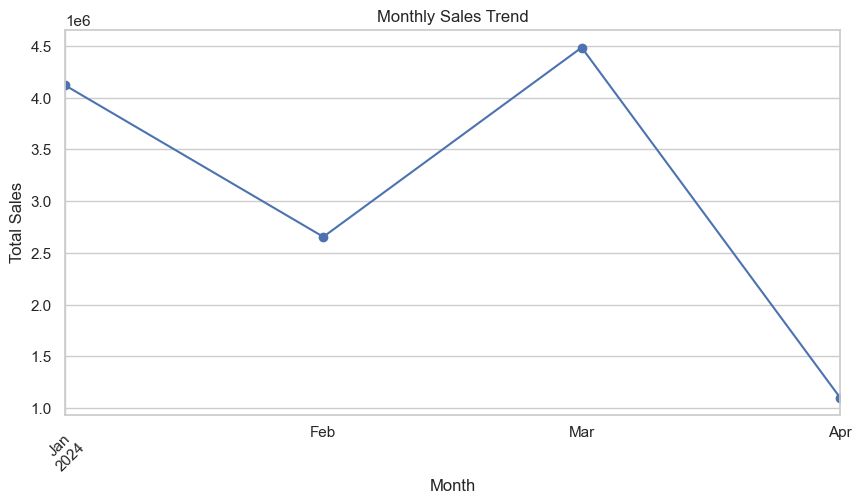

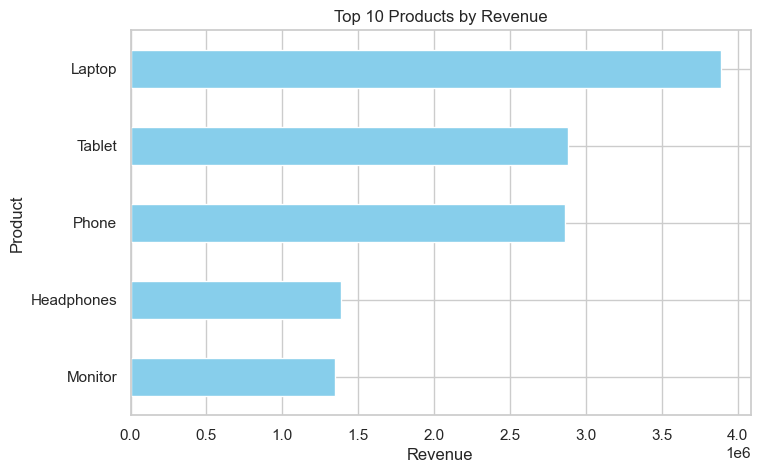

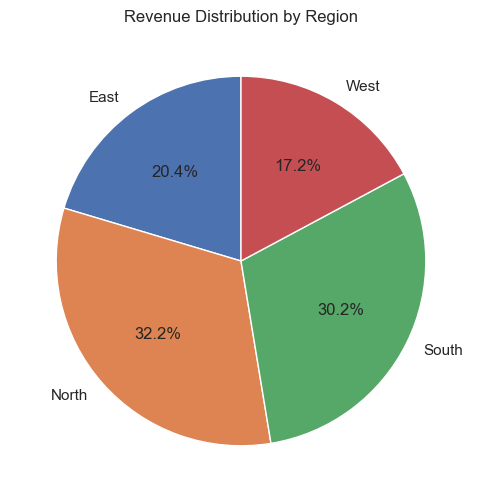


Customer Churn Distribution (%):
 Series([], Name: proportion, dtype: float64)


C:\Users\Admin\AppData\Local\Temp\ipykernel_13192\2200694703.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_13192\2200694703.py:84: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(data=df, x='Churn', palette='Set2')


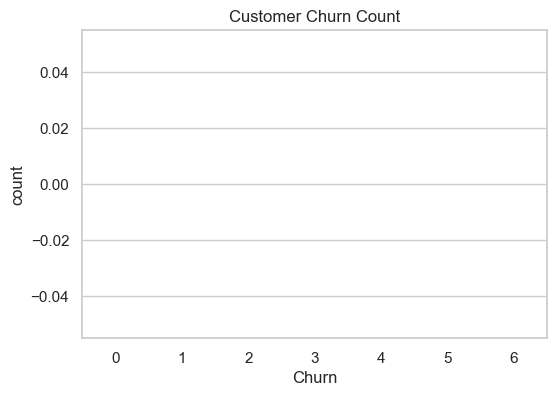

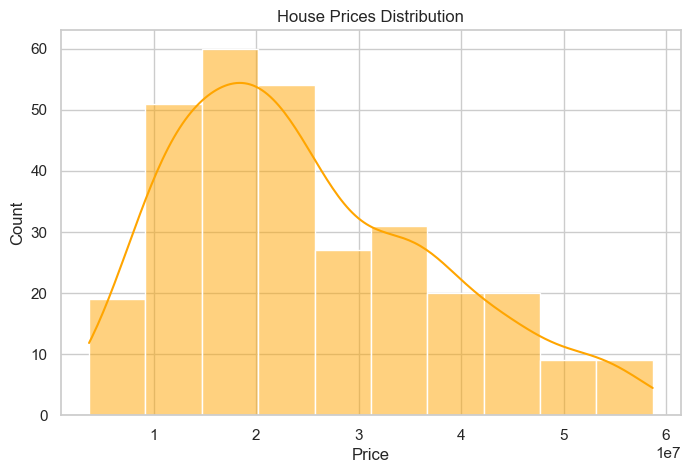


House Prices Summary:
count    3.000000e+02
mean     2.488366e+07
std      1.266525e+07
min      3.695000e+06
25%      1.527750e+07
50%      2.236500e+07
75%      3.460812e+07
max      5.870000e+07
Name: Price, dtype: float64


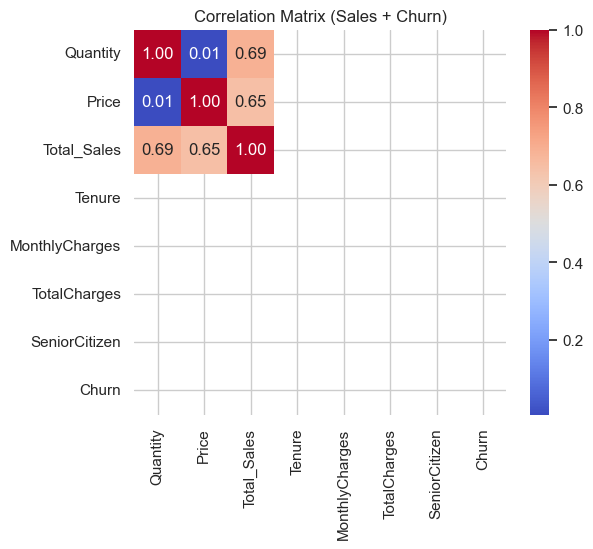


Top 5 Customers by Lifetime Value (CLV):
  Customer_ID  Total_Sales
0     CUST016       373932
1     CUST007       363870
2     CUST083       350888
3     CUST073       349510
4     CUST020       333992

📊 Key Insights:
- Top product: Laptop ($3,889,210.00)
- Region with highest revenue: North ($3,983,635.00)
- Top customer by CLV: CUST016 ($373,932.00)
- Churn rate: 0.00%
- Average House Price: $24,883,658.33

📌 Recommendations:
- Focus on top-selling products and high-performing regions.
- Engage top customers and reduce churn.
- Monitor seasonal trends in sales.
- Use house price insights for market strategy.


In [5]:
# CAPSTONE PROJECT - REAL WORLD BUSINESS ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sales = pd.read_csv("sales_data.csv")
churn = pd.read_csv("customer_churn.csv")
house_prices = pd.read_csv("house_prices.csv")

print("=== Sales Data ==="); print(sales.head()); print(sales.info())
print("\n=== Customer Churn Data ==="); print(churn.head()); print(churn.info())
print("\n=== House Prices Data ==="); print(house_prices.head()); print(house_prices.info())

sales.fillna(0, inplace=True)
churn.fillna("Unknown", inplace=True)
house_prices.fillna(0, inplace=True)

if 'Date' in sales.columns:
    sales['Date'] = pd.to_datetime(sales['Date'])

if 'Total_Sales' not in sales.columns and 'Quantity' in sales.columns and 'Price' in sales.columns:
    sales['Total_Sales'] = sales['Quantity'] * sales['Price']

df = pd.merge(sales, churn, left_on='Customer_ID', right_on='CustomerID', how='left')


if 'Date' in df.columns and 'Total_Sales' in df.columns:
    monthly_sales = df.groupby(df['Date'].dt.to_period("M"))['Total_Sales'].sum()
    plt.figure(figsize=(10,5))
    monthly_sales.plot(marker='o')
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.show()


if 'Product' in df.columns and 'Total_Sales' in df.columns:
    top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    top_products.head(10).plot(kind='barh', color='skyblue')
    plt.title("Top 10 Products by Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("Product")
    plt.gca().invert_yaxis()
    plt.show()

if 'Region' in df.columns and 'Total_Sales' in df.columns:
    region_sales = df.groupby('Region')['Total_Sales'].sum()
    plt.figure(figsize=(6,6))
    region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title("Revenue Distribution by Region")
    plt.ylabel("")
    plt.show()

if 'Churn' in df.columns:
    churn_summary = df['Churn'].value_counts(normalize=True) * 100
    print("\nCustomer Churn Distribution (%):\n", churn_summary)
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Churn', palette='Set2')
    plt.title("Customer Churn Count")
    plt.show()

if 'Price' in house_prices.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(house_prices['Price'], kde=True, color='orange')
    plt.title("House Prices Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()
    print("\nHouse Prices Summary:")
    print(house_prices['Price'].describe())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if numeric_cols:
    plt.figure(figsize=(6,5))
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix (Sales + Churn)")
    plt.show()



if 'Customer_ID' in df.columns and 'Total_Sales' in df.columns:
    clv = df.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False).reset_index()
    print("\nTop 5 Customers by Lifetime Value (CLV):")
    print(clv.head())


print("\n📊 Key Insights:")
if 'Product' in df.columns and 'Total_Sales' in df.columns:
    print(f"- Top product: {top_products.index[0]} (${top_products.iloc[0]:,.2f})")
if 'Region' in df.columns and 'Total_Sales' in df.columns:
    print(f"- Region with highest revenue: {region_sales.idxmax()} (${region_sales.max():,.2f})")
if 'Customer_ID' in df.columns and 'Total_Sales' in df.columns:
    print(f"- Top customer by CLV: {clv.iloc[0]['Customer_ID']} (${clv.iloc[0]['Total_Sales']:,.2f})")
if 'Churn' in df.columns:
    print(f"- Churn rate: {churn_summary.get('Yes', 0):.2f}%")
if 'Price' in house_prices.columns:
    print(f"- Average House Price: ${house_prices['Price'].mean():,.2f}")

print("\n Recommendations:")
print("- Focus on top-selling products and high-performing regions.")
print("- Engage top customers and reduce churn.")
print("- Monitor seasonal trends in sales.")
print("- Use house price insights for market strategy.")
